<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/AI_prog%20/ML_lab7_anomalies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")


Используется устройство: cpu


In [ ]:
ROOT_PATH = "/content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2"

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

if not os.path.exists(ROOT_PATH):
    raise FileNotFoundError(f"⚠️ Директория {ROOT_PATH} не найдена. Убедитесь, что данные загружены в Google Drive.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Путь к данным найден: /content/drive/MyDrive/archieve


In [ ]:
ROOT_PATH = "/content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2"

try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Google Drive уже смонтирован или монтирование не требуется.")

if not os.path.exists(ROOT_PATH):
    raise FileNotFoundError(f"⚠️ Директория {ROOT_PATH} не найдена. Убедитесь, что данные загружены в Google Drive.")

print("\n🔍 Содержимое корневой папки:")
for item in os.listdir(ROOT_PATH):
    print(f"  - {item}")

print("\n📂 Содержимое UCSDped1:")
ped1_path = os.path.join(ROOT_PATH, "UCSDped1")
if os.path.exists(ped1_path):
    for item in os.listdir(ped1_path):
        print(f"  - {item}")
else:
    print(f"❌ Папка UCSDped1 не найдена по пути: {ped1_path}")

print("\n📂 Содержимое UCSDped1/Test:")
train_path = os.path.join(ped1_path, "Test")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        print(f"  - {item}")
else:
    print(f"❌ Папка Test не найдена по пути: {train_path}")

print("\n📂 Содержимое UCSDped1/Train:")
train_path = os.path.join(ped1_path, "Train")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        print(f"  - {item}")
else:
    print(f"❌ Папка Train не найдена по пути: {train_path}")
#
print("\n📂 Содержимое UCSDped2:")
ped1_path = os.path.join(ROOT_PATH, "UCSDped2")
if os.path.exists(ped1_path):
    for item in os.listdir(ped1_path):
        print(f"  - {item}")
else:
    print(f"❌ Папка UCSDped2 не найдена по пути: {ped1_path}")

print("\n📂 Содержимое UCSDped2/Test:")
train_path = os.path.join(ped1_path, "Test")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        print(f"  - {item}")
else:
    print(f"❌ Папка Test не найдена по пути: {train_path}")

print("\n📂 Содержимое UCSDped2/Train:")
train_path = os.path.join(ped1_path, "Train")
if os.path.exists(train_path):
    for item in os.listdir(train_path):
        print(f"  - {item}")
else:
    print(f"❌ Папка Train не найдена по пути: {train_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔍 Содержимое корневой папки:
  - UCSDped2
  - UCSDped1

📂 Содержимое UCSDped1:
  - Test
  - Train

📂 Содержимое UCSDped1/Test:
  - UCSDped1.m~
  - ._UCSDped1.m
  - UCSDped1.m
  - Test001
  - Test003
  - Test003_gt
  - Test002
  - Test004
  - Test004_gt
  - Test005
  - Test006
  - Test008
  - Test007
  - Test009
  - Test010
  - Test013
  - Test011
  - Test014_gt
  - Test015
  - Test012
  - Test014
  - Test017
  - Test016
  - Test018
  - Test018_gt
  - Test019
  - Test020
  - Test021_gt
  - Test022
  - Test021
  - Test019_gt
  - Test022_gt
  - Test023
  - Test023_gt
  - Test024
  - Test024_gt
  - Test026
  - Test025
  - Test027
  - Test028
  - Test029
  - Test030
  - Test031
  - Test032_gt
  - Test032
  - Test033
  - Test034
  - Test035
  - Test036

📂 Содержимое UCSDped1/Train:
  - Train002
  - Train001
  - Train004
  - Train003
  - Train005
  - Train006
  - T

In [ ]:
class UCSDAnomalyDataset(Dataset):
    def __init__(self, root_dir, transform=None, train=True):
        self.root_dir = root_dir
        self.transform = transform
        self.train = train
        self.image_paths = []

        ped_dirs = ["UCSDped1", "UCSDped2"]
        for ped in ped_dirs:
            base_dir = os.path.join(root_dir, ped, "Train" if train else "Test")
            if not os.path.exists(base_dir):
                continue

            # Рекурсивно ищем все изображения
            for root, dirs, files in os.walk(base_dir):
                for file in files:
                    if file.lower().endswith(('tif')):
                        self.image_paths.append(os.path.join(root, file))

        print(f"✅ Найдено {len(self.image_paths)} изображений для {'обучения' if train else 'тестирования'}.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Ошибка при загрузке изображения {img_path}: {e}")
            image = Image.new('RGB', (64, 64))

        if self.transform:
            image = self.transform(image)

        return image, img_path

In [ ]:
class VAE(nn.Module):
    def __init__(self, input_dim=64*64*3, latent_dim=128):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), # 64->32
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1), # 32->16
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1), # 16->8
            nn.ReLU(),
            nn.Flatten()
        )

        # Latent space
        self.fc_mu = nn.Linear(128 * 8 * 8, latent_dim)
        self.fc_logvar = nn.Linear(128 * 8 * 8, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 128 * 8 * 8)
        self.decoder = nn.Sequential(
            nn.Unflatten(1, (128, 8, 8)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1), # 8->16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1), # 16->32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1), # 32->64
            nn.Sigmoid() # Выход в диапазоне [0,1]
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        return self.decoder(self.decoder_input(z))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar

In [ ]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


In [ ]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

train_dataset = UCSDAnomalyDataset(ROOT_PATH, transform=transform, train=True)
test_dataset = UCSDAnomalyDataset(ROOT_PATH, transform=transform, train=False)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


✅ Найдено 9350 изображений для обучения.
✅ Найдено 9210 изображений для тестирования.


In [ ]:
# --- Инициализация модели, оптимизатора и функции потерь ---
model = VAE(input_dim=64*64*3, latent_dim=128).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

    for data, _ in progress_bar:
        data = data.to(device)
        optimizer.zero_grad()

        recon_batch, mu, logvar = model(data)
        loss = vae_loss(recon_batch, data, mu, logvar)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}, Average Loss: {avg_train_loss:.4f}')


Epoch 1/10: 100%|██████████| 293/293 [07:19<00:00,  1.50s/it, Loss=46058.6758]


Epoch 1, Average Loss: 7453.6022


Epoch 2/10: 100%|██████████| 293/293 [01:42<00:00,  2.86it/s, Loss=44076.4805]


Epoch 2, Average Loss: 7344.3035


Epoch 3/10: 100%|██████████| 293/293 [01:46<00:00,  2.76it/s, Loss=44460.8398]


...

Epoch 8, Average Loss: 7318.3760


Epoch 9/10: 100%|██████████| 293/293 [01:46<00:00,  2.75it/s, Loss=44399.2500]


Epoch 9, Average Loss: 7317.1673


Epoch 10/10: 100%|██████████| 293/293 [01:45<00:00,  2.77it/s, Loss=44010.6133]

Epoch 10, Average Loss: 7316.3117


In [ ]:
# --- Тестирование и обнаружение аномалий ---
model.eval()
anomaly_scores = []
original_images = []
reconstructed_images = []
image_paths = []

with torch.no_grad():
    for data, paths in tqdm(test_loader, desc="Тестирование"):
        data = data.to(device)
        recon_data, mu, logvar = model(data)

        mse = ((data - recon_data) ** 2).view(data.size(0), -1).mean(dim=1)
        anomaly_scores.extend(mse.cpu().numpy())

        original_images.extend(data.cpu())
        reconstructed_images.extend(recon_data.cpu())
        image_paths.extend(paths)

anomaly_scores = np.array(anomaly_scores)

Тестирование:  34%|███▎      | 97/288 [00:23<00:41,  4.58it/s]

Ошибка при загрузке изображения /content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test017/142.tif: decoder error -2


Тестирование: 100%|██████████| 288/288 [01:07<00:00,  4.26it/s]


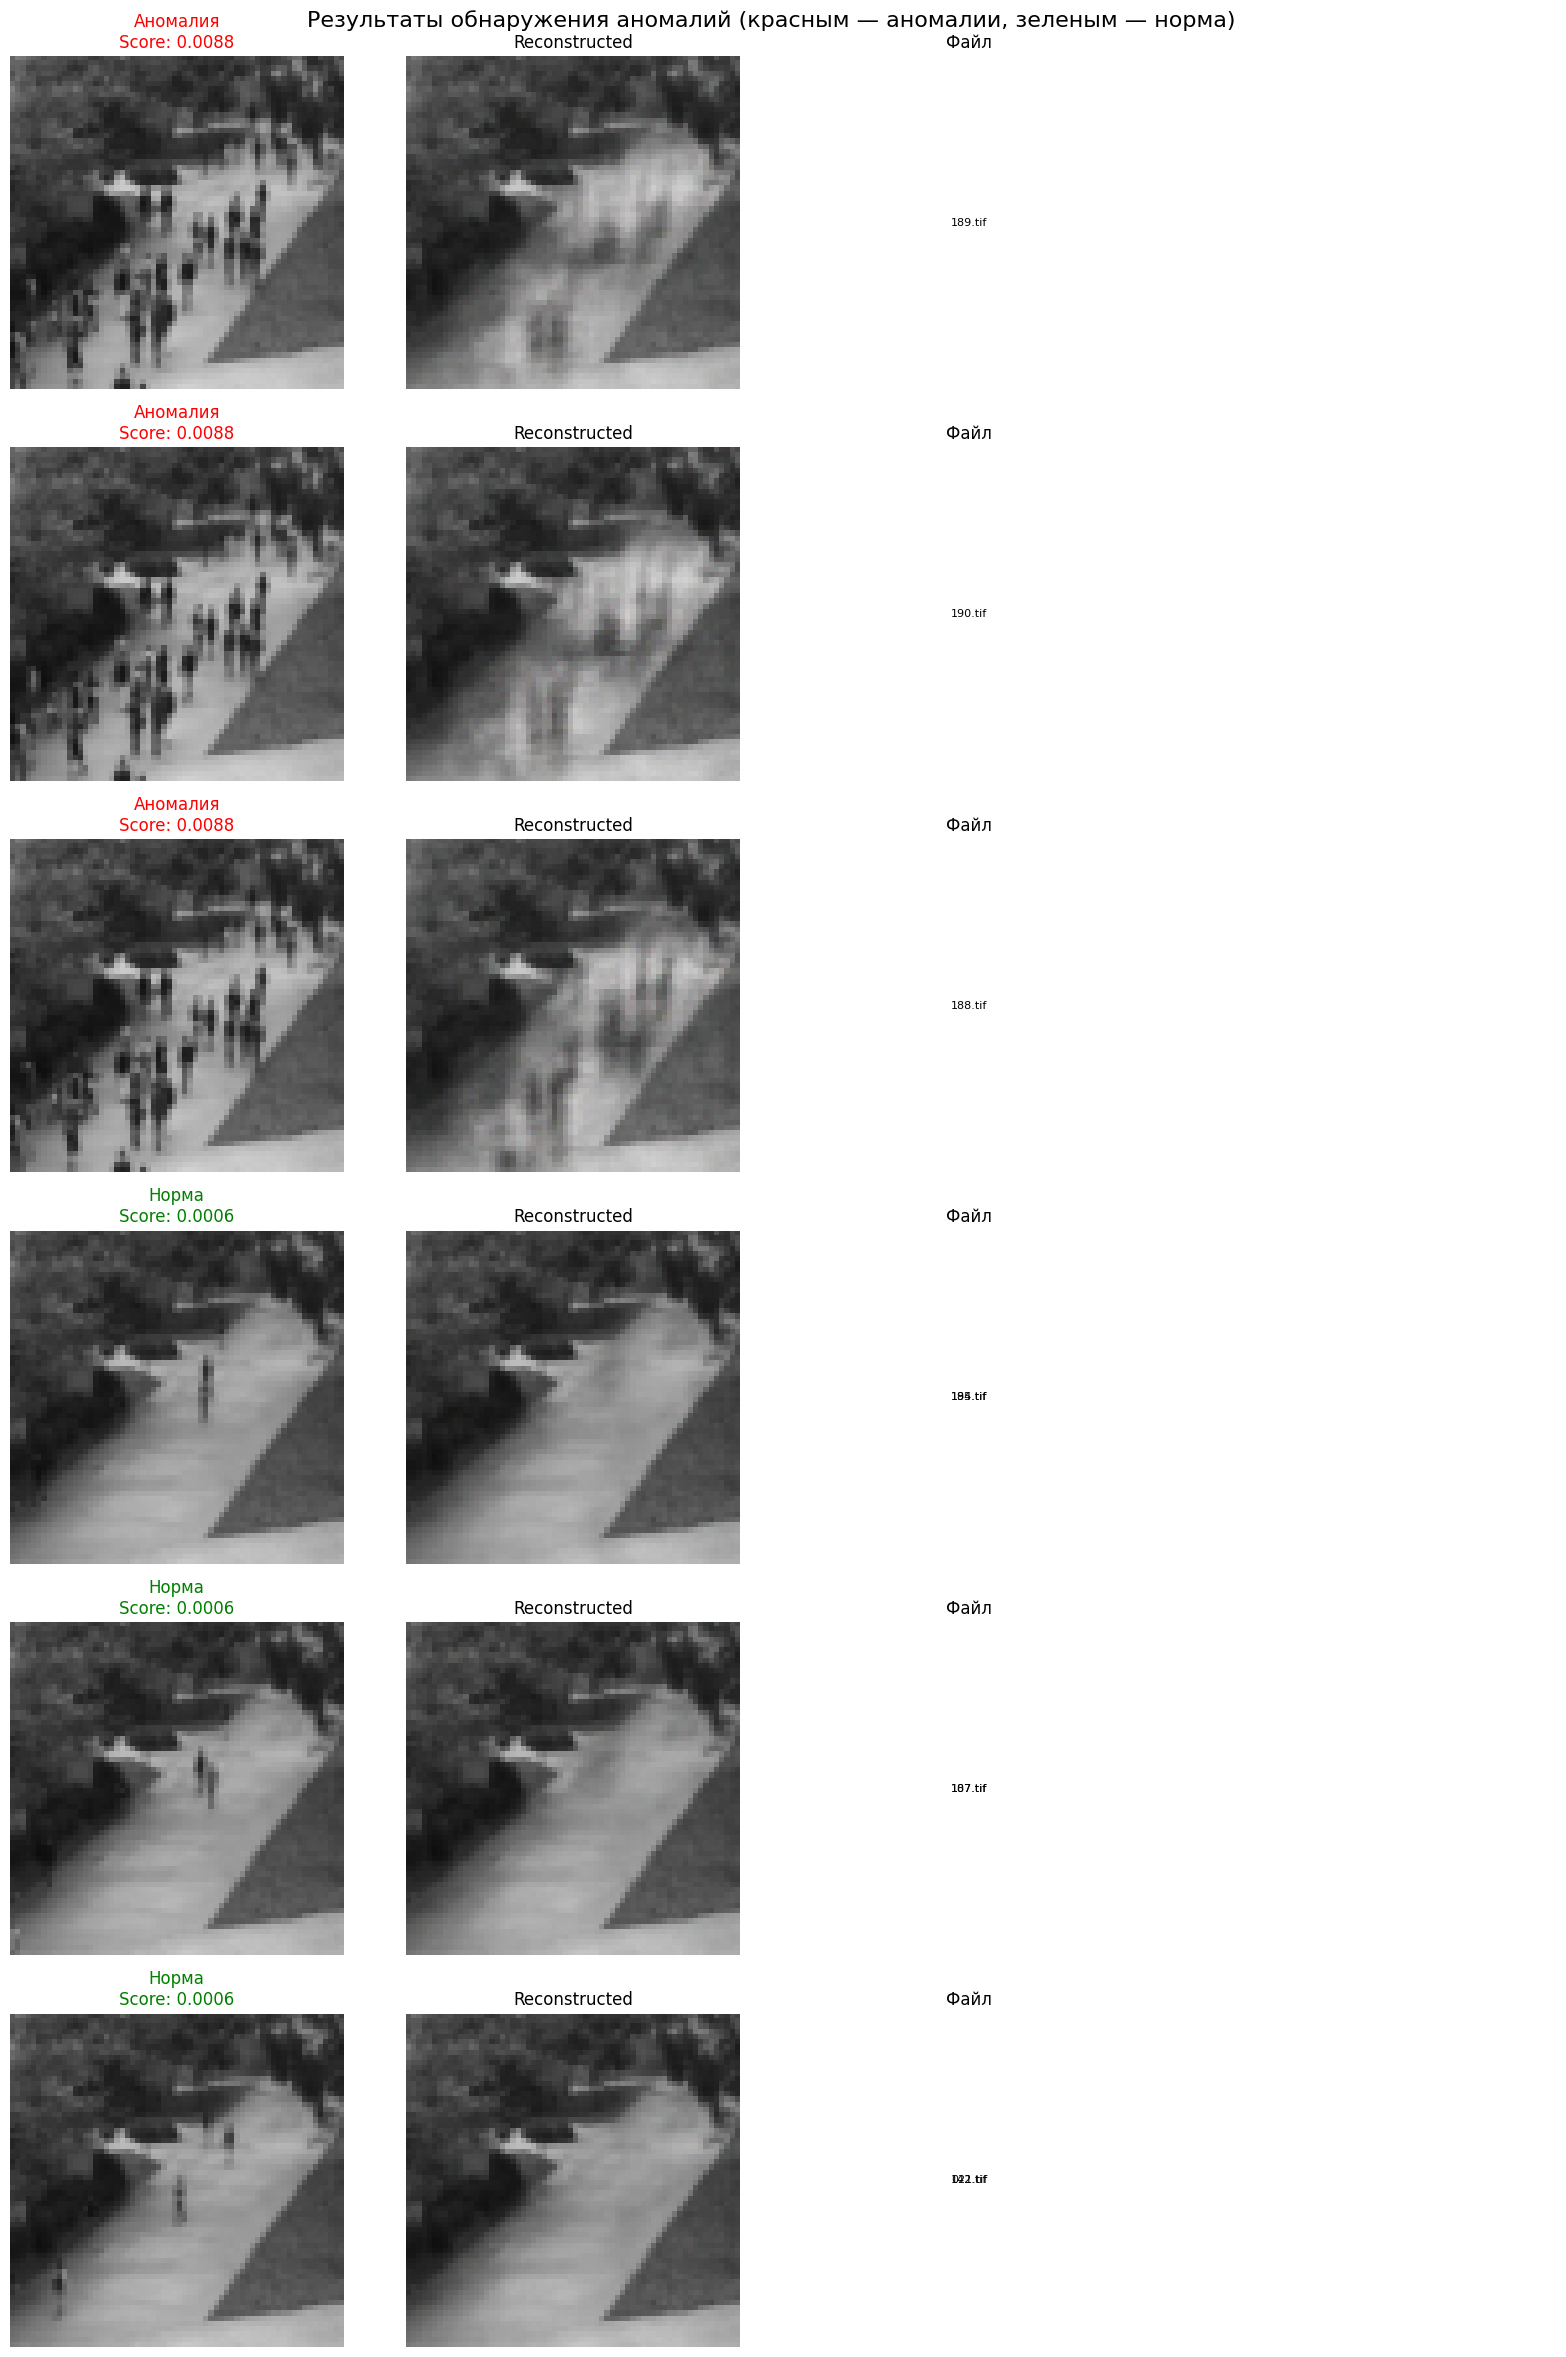

In [ ]:
top_anomalies_idx = np.argsort(anomaly_scores)[-6:]
normal_idx = np.argsort(anomaly_scores)[:6]

fig, axes = plt.subplots(6, 4, figsize=(16, 24))
fig.suptitle('Результаты обнаружения аномалий (красным — аномалии, зеленым — норма)', fontsize=16)

for i, idx in enumerate(top_anomalies_idx):
    ax = axes[i, 0]
    ax.imshow(original_images[idx].permute(1, 2, 0).numpy())
    ax.set_title(f'Аномалия\nScore: {anomaly_scores[idx]:.4f}', color='red')
    ax.axis('off')

    ax = axes[i, 1]
    ax.imshow(reconstructed_images[idx].permute(1, 2, 0).numpy())
    ax.set_title('Reconstructed')
    ax.axis('off')

    ax = axes[i, 2]
    ax.text(0.5, 0.5, f"{os.path.basename(image_paths[idx])}", ha='center', va='center', wrap=True, fontsize=8)
    ax.set_title('Файл')
    ax.axis('off')

    ax = axes[i, 3]
    ax.axis('off')

normal_idx = normal_idx[:3]

for i, idx in enumerate(normal_idx):
    row = i + 3
    ax = axes[row, 0]
    ax.imshow(original_images[idx].permute(1, 2, 0).numpy())
    ax.set_title(f'Норма\nScore: {anomaly_scores[idx]:.4f}', color='green')
    ax.axis('off')

    ax = axes[row, 1]
    ax.imshow(reconstructed_images[idx].permute(1, 2, 0).numpy())
    ax.set_title('Reconstructed')
    ax.axis('off')

    ax = axes[row, 2]
    ax.text(0.5, 0.5, f"{os.path.basename(image_paths[idx])}", ha='center', va='center', wrap=True, fontsize=8)
    ax.set_title('Файл')
    ax.axis('off')

    ax = axes[row, 3]
    ax.axis('off')

plt.tight_layout()
plt.show()


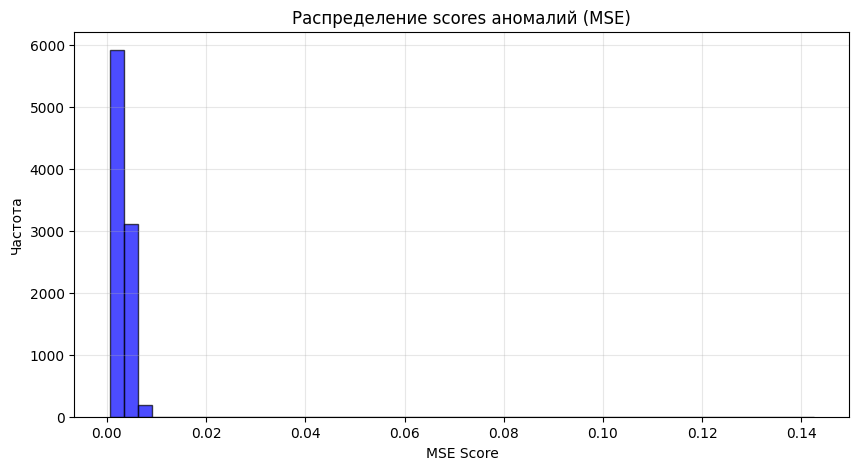

📌 Порог для обнаружения аномалий (95-й перцентиль): 0.0057
🔍 Обнаружено аномалий: 461 из 9210 (5.0%)

📁 Примеры файлов, классифицированных как аномалии:
  - /content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test001/061.tif
  - /content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test001/062.tif
  - /content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test001/083.tif
  - /content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test001/065.tif
  - /content/drive/MyDrive/archieve/UCSD_Anomaly_Dataset.v1p2/UCSDped1/Test/Test001/074.tif


In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(anomaly_scores, bins=50, alpha=0.7, color='blue', edgecolor='black')
plt.title('Распределение scores аномалий (MSE)')
plt.xlabel('MSE Score')
plt.ylabel('Частота')
plt.grid(True, alpha=0.3)
plt.show()

threshold = np.percentile(anomaly_scores, 95)
print(f"📌 Порог для обнаружения аномалий (95-й перцентиль): {threshold:.4f}")

predicted_anomalies = anomaly_scores > threshold
print(f"🔍 Обнаружено аномалий: {np.sum(predicted_anomalies)} из {len(anomaly_scores)} ({np.sum(predicted_anomalies)/len(anomaly_scores)*100:.1f}%)")

print("\n📁 Примеры файлов, классифицированных как аномалии:")
for file in [image_paths[i] for i in range(len(image_paths)) if predicted_anomalies[i]][:5]:
    print(f"  - {file}")